# Is the Earth Getting Shakier?

Counting significant earthquakes (magnitude 5.0+) per year since 1990, worldwide, using the USGS global earthquake catalogue. Spoiler: the rise in the mid-2000s is mostly a story about better global seismic monitoring, not a shakier planet — but a few individual spikes (2011) are very real.

Data source: **USGS Earthquake Hazards Program** — public API, no API key required.

In [1]:
import time

import matplotlib.pyplot as plt
import requests

API = "https://earthquake.usgs.gov/fdsnws/event/1/count"
HEADERS = {"User-Agent": "Mozilla/5.0"}
START_YEAR = 1990
END_YEAR = 2025
MIN_MAGNITUDE = 5.0


def quakes_in_year(year: int) -> int:
    params = {
        "starttime": f"{year}-01-01",
        "endtime": f"{year + 1}-01-01",
        "minmagnitude": MIN_MAGNITUDE,
    }
    response = requests.get(API, params=params, headers=HEADERS, timeout=20)
    response.raise_for_status()
    return int(response.text)


years = list(range(START_YEAR, END_YEAR + 1))
counts = []
for year in years:
    counts.append(quakes_in_year(year))
    time.sleep(0.3)

counts[:5]

[1768, 1586, 1672, 1566, 1691]

## Earthquakes per year

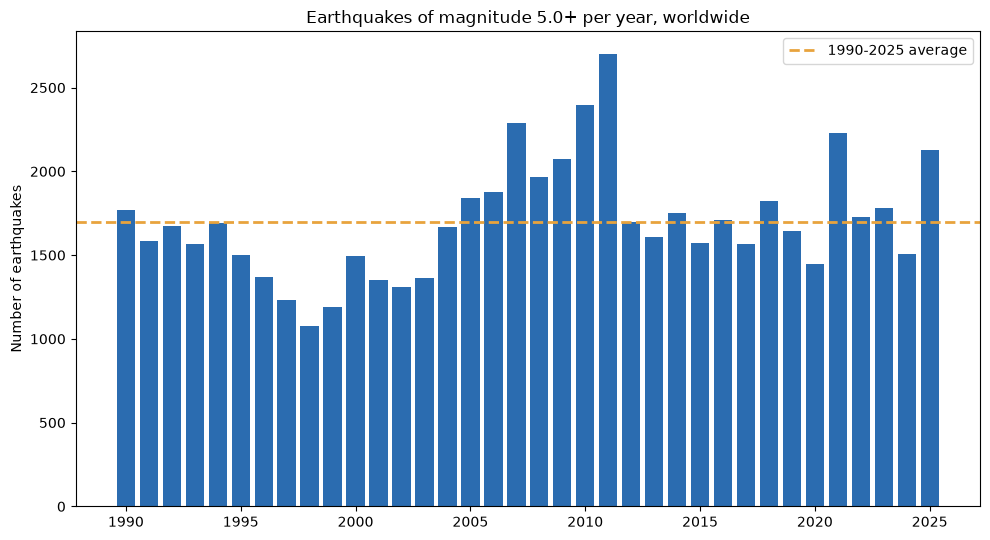

In [2]:
mean_count = sum(counts) / len(counts)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(years, counts, color="#2b6cb0")
ax.axhline(mean_count, color="#e8a33d", linewidth=2, linestyle="--", label=f"{START_YEAR}-{END_YEAR} average")

ax.set_title(f"Earthquakes of magnitude {MIN_MAGNITUDE}+ per year, worldwide")
ax.set_ylabel("Number of earthquakes")
ax.legend()
fig.tight_layout()
plt.show()

## Busiest and quietest years

In [3]:
busiest_year = years[counts.index(max(counts))]
quietest_year = years[counts.index(min(counts))]

print(f"Average M{MIN_MAGNITUDE}+ earthquakes per year: {mean_count:.0f}")
print(f"Busiest year: {busiest_year} ({max(counts)} earthquakes)")
print(f"Quietest year: {quietest_year} ({min(counts)} earthquakes)")

Average M5.0+ earthquakes per year: 1700
Busiest year: 2011 (2701 earthquakes)
Quietest year: 1998 (1078 earthquakes)
